In [1]:
# ============================================================
# FUNCTION 5 — WEEK 5 CLEAN REBUILD
# ============================================================

import numpy as np

from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel
)

# ------------------------------------------------------------
# 1. Load original Function 5 data
# ------------------------------------------------------------

X = np.load("function5/initial_inputs.npy")
Y = np.load("function5/initial_outputs.npy").reshape(-1)

# ------------------------------------------------------------
# 2. Add Weeks 1–4 exactly once
# ------------------------------------------------------------

week1_x = np.array([
    [0.377511, 0.871594, 0.988652, 0.967795]
])
week1_y = np.array([
    2687.686511102482
])

week2_x = np.array([
    [0.398348, 0.896184, 0.926939, 0.972836]
])
week2_y = np.array([
    2360.0402820167205
])

week3_x = np.array([
    [0.359181, 0.928233, 1.000000, 1.000000]
])
week3_y = np.array([
    3650.138639563766
])

week4_x = np.array([
    [0.479181, 1.000000, 1.000000, 1.000000]
])
week4_y = np.array([
    4641.863904371854
])

X = np.vstack([
    X,
    week1_x,
    week2_x,
    week3_x,
    week4_x
])

Y = np.concatenate([
    Y,
    week1_y,
    week2_y,
    week3_y,
    week4_y
])

best_index = np.argmax(Y)
best_x = X[best_index]
best_y = Y[best_index]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("\nBest observed input:", best_x)
print("Best observed output:", best_y)

# ------------------------------------------------------------
# 3. Scale the outputs
#
# Function 5 outputs are much larger than the other functions,
# so scaling improves numerical stability.
# ------------------------------------------------------------

Y_mean = Y.mean()
Y_std = Y.std()

Y_scaled = (Y - Y_mean) / Y_std

print("\nOutput mean:", Y_mean)
print("Output standard deviation:", Y_std)

# ------------------------------------------------------------
# 4. Fit an ARD Gaussian Process
# ------------------------------------------------------------

kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(
        length_scale=np.array([0.25, 0.25, 0.20, 0.25]),
        length_scale_bounds=(0.01, 3.0),
        nu=2.5
    )
    + WhiteKernel(
        noise_level=1e-5,
        noise_level_bounds=(1e-10, 1e-1)
    )
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=False,
    n_restarts_optimizer=25,
    random_state=55
)

gp.fit(X, Y_scaled)

print("\nFitted kernel:")
print(gp.kernel_)

# ------------------------------------------------------------
# 5. Inspect fitted lengthscales
# ------------------------------------------------------------

lengthscales = np.asarray(
    gp.kernel_.k1.k2.length_scale
)

importance = 1 / lengthscales
importance = importance / importance.sum()

print("\nFitted lengthscales:", lengthscales)
print("Normalised input influence:")

for i, value in enumerate(importance, start=1):
    print(f"x{i}: {value:.4f}")

# ------------------------------------------------------------
# 6. Generate Week 5 candidates
#
# Most candidates keep x2, x3 and x4 near 1.
# x1 is explored more widely because increasing it from
# Week 3 to Week 4 produced a large improvement.
# ------------------------------------------------------------

rng = np.random.default_rng(55)

# Directly explore the upper boundary
boundary_x1 = rng.uniform(
    max(0, best_x[0] - 0.04),
    min(1, best_x[0] + 0.25),
    size=25_000
)

boundary_candidates = np.column_stack([
    boundary_x1,
    np.ones(25_000),
    np.ones(25_000),
    np.ones(25_000)
])

# Search just below the boundary
near_boundary_candidates = np.column_stack([
    rng.uniform(
        max(0, best_x[0] - 0.05),
        min(1, best_x[0] + 0.25),
        size=20_000
    ),
    rng.uniform(0.97, 1.00, size=20_000),
    rng.uniform(0.97, 1.00, size=20_000),
    rng.uniform(0.97, 1.00, size=20_000)
])

# Very local refinement around Week 4
very_local = rng.normal(
    loc=best_x,
    scale=[0.015, 0.006, 0.006, 0.006],
    size=(15_000, 4)
)

# Wider local search
local = rng.normal(
    loc=best_x,
    scale=[0.060, 0.020, 0.020, 0.020],
    size=(15_000, 4)
)

# Limited global exploration
global_candidates = rng.uniform(
    0,
    1,
    size=(5_000, 4)
)

candidates = np.vstack([
    boundary_candidates,
    near_boundary_candidates,
    very_local,
    local,
    global_candidates
])

candidates = np.clip(candidates, 0, 1)

# ------------------------------------------------------------
# 7. Remove candidates too close to existing observations
# ------------------------------------------------------------

distances = np.linalg.norm(
    candidates[:, None, :] - X[None, :, :],
    axis=2
)

minimum_distance = distances.min(axis=1)

candidates = candidates[
    minimum_distance > 0.004
]

# ------------------------------------------------------------
# 8. Predict candidate performance
# ------------------------------------------------------------

mean_scaled, std_scaled = gp.predict(
    candidates,
    return_std=True
)

# Convert predictions back to the original output scale
mean = mean_scaled * Y_std + Y_mean
std = std_scaled * Y_std

# ------------------------------------------------------------
# 9. Expected Improvement and UCB
# ------------------------------------------------------------

xi = 10.0

improvement = mean - best_y - xi

with np.errstate(divide="ignore", invalid="ignore"):
    z = improvement / std

    expected_improvement = (
        improvement * norm.cdf(z)
        + std * norm.pdf(z)
    )

expected_improvement[std < 1e-12] = 0

# Low kappa because Function 5 has a very strong established region
kappa = 0.45
ucb = mean + kappa * std

# ------------------------------------------------------------
# 10. Restrict attention to credible high-output candidates
# ------------------------------------------------------------

mean_filter = mean >= (best_y - 500)

if np.sum(mean_filter) < 100:
    mean_filter = mean >= np.percentile(mean, 90)

filtered_candidates = candidates[mean_filter]
filtered_mean = mean[mean_filter]
filtered_std = std[mean_filter]
filtered_ei = expected_improvement[mean_filter]
filtered_ucb = ucb[mean_filter]

ei_normalised = (
    filtered_ei - filtered_ei.min()
) / (
    filtered_ei.max()
    - filtered_ei.min()
    + 1e-12
)

ucb_normalised = (
    filtered_ucb - filtered_ucb.min()
) / (
    filtered_ucb.max()
    - filtered_ucb.min()
    + 1e-12
)

# Strong exploitation with a small uncertainty component
acquisition = (
    0.85 * ei_normalised
    + 0.15 * ucb_normalised
)

best_candidate_index = np.argmax(acquisition)
week5_query = filtered_candidates[best_candidate_index]

# ------------------------------------------------------------
# 11. Print the proposed Week 5 query
# ------------------------------------------------------------

print("\nMethod:")
print("Boundary-focused local Expected Improvement with small UCB component")

print("\nCandidates passing mean filter:",
      len(filtered_candidates))

print("\nSuggested Week 5 query:")
print(week5_query)

print("\nPortal format:")
print("-".join(
    f"{value:.6f}"
    for value in week5_query
))

print("\nPredicted mean:",
      filtered_mean[best_candidate_index])

print("Predicted standard deviation:",
      filtered_std[best_candidate_index])

print("Expected Improvement:",
      filtered_ei[best_candidate_index])

print("UCB:",
      filtered_ucb[best_candidate_index])

print("Distance from Week 4 point:",
      np.linalg.norm(
          week5_query - week4_x[0]
      ))

X shape: (24, 4)
Y shape: (24,)

Best observed input: [0.479181 1.       1.       1.      ]
Best observed output: 4641.863904371854

Output mean: 681.8819521097951
Output standard deviation: 1261.09351431216


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



Fitted kernel:
1.4**2 * Matern(length_scale=[3, 0.469, 0.531, 3], nu=2.5) + WhiteKernel(noise_level=1e-10)

Fitted lengthscales: [3.         0.46932947 0.53051241 3.        ]
Normalised input influence:
x1: 0.0712
x2: 0.4551
x3: 0.4026
x4: 0.0712

Method:
Boundary-focused local Expected Improvement with small UCB component

Candidates passing mean filter: 70005

Suggested Week 5 query:
[0.72914869 1.         1.         1.        ]

Portal format:
0.729149-1.000000-1.000000-1.000000

Predicted mean: 4703.151988376036
Predicted standard deviation: 118.00236523209678
Expected Improvement: 77.09801699427581
UCB: 4756.253052730479
Distance from Week 4 point: 0.2499676863227575


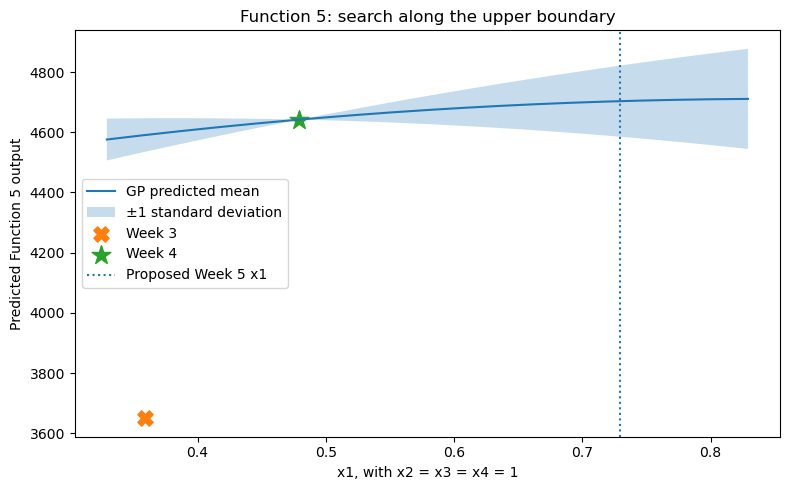

In [2]:
# ------------------------------------------------------------
# 12. Plot predicted output along the upper boundary
# ------------------------------------------------------------

import matplotlib.pyplot as plt

x1_values = np.linspace(
    max(0, best_x[0] - 0.15),
    min(1, best_x[0] + 0.35),
    400
)

boundary_slice = np.column_stack([
    x1_values,
    np.ones_like(x1_values),
    np.ones_like(x1_values),
    np.ones_like(x1_values)
])

slice_mean_scaled, slice_std_scaled = gp.predict(
    boundary_slice,
    return_std=True
)

slice_mean = slice_mean_scaled * Y_std + Y_mean
slice_std = slice_std_scaled * Y_std

plt.figure(figsize=(8, 5))

plt.plot(
    x1_values,
    slice_mean,
    label="GP predicted mean"
)

plt.fill_between(
    x1_values,
    slice_mean - slice_std,
    slice_mean + slice_std,
    alpha=0.25,
    label="±1 standard deviation"
)

plt.scatter(
    week3_x[0, 0],
    week3_y[0],
    marker="X",
    s=120,
    label="Week 3"
)

plt.scatter(
    week4_x[0, 0],
    week4_y[0],
    marker="*",
    s=200,
    label="Week 4"
)

plt.axvline(
    week5_query[0],
    linestyle=":",
    label="Proposed Week 5 x1"
)

plt.xlabel("x1, with x2 = x3 = x4 = 1")
plt.ylabel("Predicted Function 5 output")
plt.title("Function 5: search along the upper boundary")
plt.legend()
plt.tight_layout()
plt.show()